# Limpieza y Modelado Logistico con Random Forest

Notebook para cargar `dataset_logistico.csv`, limpiar las variables necesarias y entrenar un modelo `RandomForestRegressor` para predecir `sale_amount`.

## 1. Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Carga del dataset

In [ ]:


df = pd.read_csv("../../data/dataset_logistico.csv")

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")
df.head()

Filas: 92,216
Columnas: 20


,dt,sale_amount,product_id,store_id,first_category_id,second_category_id,third_category_id,discount,holiday_flag,activity_flag,mes,dia_mes,dia_semana,fin_semana,horas_con_stock,venta_lag_1,venta_lag_7,venta_promedio_7d,venta_promedio_14d,stock_lag_1
0,2024-04-04,5.4,001,0,20,50,24,0.997,1,0,4,4,3,0,4,1.9,3.4,3.357143,3.357143,0.0
1,2024-04-04,0.6,R154,1,21,61,224,1.000,1,0,4,4,3,0,12,0.3,0.1,0.457143,0.457143,0.0
2,2024-04-04,0.6,R170,34,24,51,145,1.000,1,0,4,4,3,0,18,0.6,0.5,0.481429,0.481429,7.0
3,2024-04-04,0.4,R153,1,21,61,178,1.000,1,0,4,4,3,0,4,0.1,0.4,0.257143,0.257143,0.0
4,2024-04-04,0.6,R173,34,31,79,230,0.849,1,1,4,4,3,0,0,0.3,0.4,0.428571,0.428571,0.0


## 3. Revision inicial

In [3]:
df.info()

print("\nValores nulos por columna:")
display(df.isna().sum().sort_values(ascending=False).to_frame("nulos"))

print(f"\nFilas duplicadas: {df.duplicated().sum():,}")

display(df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 92216 entries, 0 to 92215
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   dt                  92216 non-null  str    
 1   sale_amount         92216 non-null  float64
 2   product_id          92216 non-null  str    
 3   store_id            92216 non-null  int64  
 4   first_category_id   92216 non-null  int64  
 5   second_category_id  92216 non-null  int64  
 6   third_category_id   92216 non-null  int64  
 7   discount            92216 non-null  float64
 8   holiday_flag        92216 non-null  int64  
 9   activity_flag       92216 non-null  int64  
 10  mes                 92216 non-null  int64  
 11  dia_mes             92216 non-null  int64  
 12  dia_semana          92216 non-null  int64  
 13  fin_semana          92216 non-null  int64  
 14  horas_con_stock     92216 non-null  int64  
 15  venta_lag_1         92216 non-null  float64
 16  venta_lag_7    

,nulos
dt,0
sale_amount,0
product_id,0
store_id,0
first_category_id,0
second_category_id,0
third_category_id,0
discount,0
holiday_flag,0
activity_flag,0



Filas duplicadas: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dt,92216,83,2024-04-04,1112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sale_amount,92216.0,NaN,NaN,NaN,1.049589,1.20195,0.0,0.4,0.7,1.2,22.9
product_id,92216,273,010,1079,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_id,92216.0,NaN,NaN,NaN,19.049482,14.042589,0.0,2.0,18.0,29.0,46.0
first_category_id,92216.0,NaN,NaN,NaN,14.690412,8.944052,0.0,4.0,16.0,21.0,31.0
second_category_id,92216.0,NaN,NaN,NaN,44.088488,21.832804,0.0,28.0,33.0,64.0,82.0
third_category_id,92216.0,NaN,NaN,NaN,111.941203,60.44569,0.0,66.0,105.0,167.0,232.0
discount,92216.0,NaN,NaN,NaN,0.912618,0.114868,0.358,0.85,0.984,1.0,1.0
holiday_flag,92216.0,NaN,NaN,NaN,0.349419,0.476789,0.0,0.0,0.0,1.0,1.0
activity_flag,92216.0,NaN,NaN,NaN,0.40468,0.490833,0.0,0.0,0.0,1.0,1.0


## 4. Limpieza y preparacion

In [4]:
df = df.copy()

df["dt"] = pd.to_datetime(df["dt"], errors="coerce")

# Eliminamos filas con problemas basicos en fecha o variable objetivo.
df = df.dropna(subset=["dt", "sale_amount"]).copy()

# Eliminamos duplicados exactos.
df = df.drop_duplicates().copy()

# Codificacion simple con pandas para variables categoricas.
columnas_categoricas = [
    "product_id",
    "store_id",
    "first_category_id",
    "second_category_id",
    "third_category_id",
    "holiday_flag",
    "activity_flag",
]

for col in columnas_categoricas:
    if col in df.columns:
        df[col] = df[col].astype("category")
        df[f"{col}_cod"] = df[col].cat.codes

print(f"Filas despues de limpieza: {len(df):,}")
display(df.head())

Filas despues de limpieza: 92,216


,dt,sale_amount,product_id,store_id,first_category_id,second_category_id,third_category_id,discount,holiday_flag,activity_flag,mes,dia_mes,dia_semana,fin_semana,horas_con_stock,venta_lag_1,venta_lag_7,venta_promedio_7d,venta_promedio_14d,stock_lag_1,product_id_cod,store_id_cod,first_category_id_cod,second_category_id_cod,third_category_id_cod,holiday_flag_cod,activity_flag_cod
0,2024-04-04,5.4,001,0,20,50,24,0.997,1,0,4,4,3,0,4,1.9,3.4,3.357143,3.357143,0.0,0,0,14,35,15,1,0
1,2024-04-04,0.6,R154,1,21,61,224,1.000,1,0,4,4,3,0,12,0.3,0.1,0.457143,0.457143,0.0,153,1,15,44,142,1,0
2,2024-04-04,0.6,R170,34,24,51,145,1.000,1,0,4,4,3,0,18,0.6,0.5,0.481429,0.481429,7.0,169,9,18,36,91,1,0
3,2024-04-04,0.4,R153,1,21,61,178,1.000,1,0,4,4,3,0,4,0.1,0.4,0.257143,0.257143,0.0,152,1,15,44,115,1,0
4,2024-04-04,0.6,R173,34,31,79,230,0.849,1,1,4,4,3,0,0,0.3,0.4,0.428571,0.428571,0.0,172,9,24,60,147,1,1


## 5. Variables para el modelo

In [5]:
TARGET = "sale_amount"

FEATURES = [
    "product_id_cod",
    "store_id_cod",
    "first_category_id_cod",
    "second_category_id_cod",
    "third_category_id_cod",
    "discount",
    "holiday_flag_cod",
    "activity_flag_cod",
    "mes",
    "dia_mes",
    "dia_semana",
    "fin_semana",
    "horas_con_stock",
    "venta_lag_1",
    "venta_lag_7",
    "venta_promedio_7d",
    "venta_promedio_14d",
    "stock_lag_1",
]

features_existentes = [col for col in FEATURES if col in df.columns]

df_modelo = df[["dt", TARGET] + features_existentes].dropna().sort_values("dt").reset_index(drop=True)

print("Target:", TARGET)
print("Features utilizadas:")
for feature in features_existentes:
    print("-", feature)

print(f"\nFilas finales para modelado: {len(df_modelo):,}")
display(df_modelo.head())

Target: sale_amount
Features utilizadas:
- product_id_cod
- store_id_cod
- first_category_id_cod
- second_category_id_cod
- third_category_id_cod
- discount
- holiday_flag_cod
- activity_flag_cod
- mes
- dia_mes
- dia_semana
- fin_semana
- horas_con_stock
- venta_lag_1
- venta_lag_7
- venta_promedio_7d
- venta_promedio_14d
- stock_lag_1

Filas finales para modelado: 92,216


,dt,sale_amount,product_id_cod,store_id_cod,first_category_id_cod,second_category_id_cod,third_category_id_cod,discount,holiday_flag_cod,activity_flag_cod,mes,dia_mes,dia_semana,fin_semana,horas_con_stock,venta_lag_1,venta_lag_7,venta_promedio_7d,venta_promedio_14d,stock_lag_1
0,2024-04-04,5.4,0,0,14,35,15,0.997,1,0,4,4,3,0,4,1.9,3.4,3.357143,3.357143,0.0
1,2024-04-04,4.1,0,6,14,35,15,1.000,1,0,4,4,3,0,9,2.8,3.3,3.200000,3.200000,2.0
2,2024-04-04,0.4,210,5,13,61,74,0.966,1,1,4,4,3,0,0,0.2,0.6,0.542857,0.542857,0.0
3,2024-04-04,0.3,209,5,13,61,74,1.000,1,0,4,4,3,0,0,0.2,0.5,0.485714,0.485714,0.0
4,2024-04-04,2.5,1,6,3,21,1,1.000,1,0,4,4,3,0,14,4.4,0.1,3.871429,3.871429,0.0


## 6. Division cronologica train-test

In [6]:
X = df_modelo.drop(["dt", TARGET], axis=1)
y = df_modelo[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Train: {len(X_train):,} filas")
print(f"Test: {len(X_test):,} filas")
print(f"Columnas predictoras: {X_train.shape[1]}")

Train: 73,772 filas
Test: 18,444 filas
Fecha minima train: 2024-04-04 00:00:00
Fecha maxima train: 2024-06-09 00:00:00
Fecha minima test: 2024-06-09 00:00:00
Fecha maxima test: 2024-06-25 00:00:00


## 7. Entrenamiento con RandomForestRegressor

In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


## 8. Evaluacion

In [8]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

resultados = pd.DataFrame({
    "dt": df_modelo.loc[X_test.index, "dt"].values,
    "real": y_test.values,
    "pred": y_pred,
    "error_abs": np.abs(y_test.values - y_pred)
})

display(resultados.head())

MAE  : 0.3533
RMSE : 0.5789
R2   : 0.8043


,dt,real,pred,error_abs
0,2024-06-09,0.4,0.610924,0.210924
1,2024-06-09,1.3,1.096114,0.203886
2,2024-06-09,1.0,1.175483,0.175483
3,2024-06-09,0.2,0.613530,0.413530
4,2024-06-09,1.1,0.819934,0.280066


## 9. Graficos del modelo

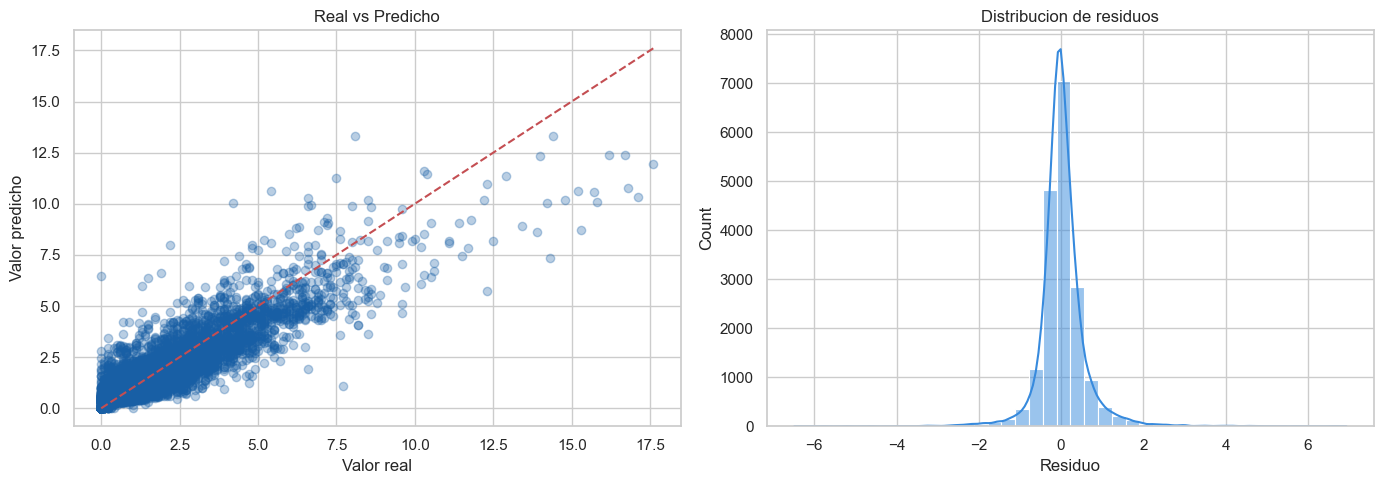

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, color="#185FA5")
limites = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limites, limites, "r--")
axes[0].set_title("Real vs Predicho")
axes[0].set_xlabel("Valor real")
axes[0].set_ylabel("Valor predicho")

residuos = y_test.values - y_pred
sns.histplot(residuos, bins=40, kde=True, ax=axes[1], color="#378ADD")
axes[1].set_title("Distribucion de residuos")
axes[1].set_xlabel("Residuo")

plt.tight_layout()
plt.show()

## 10. Importancia de variables

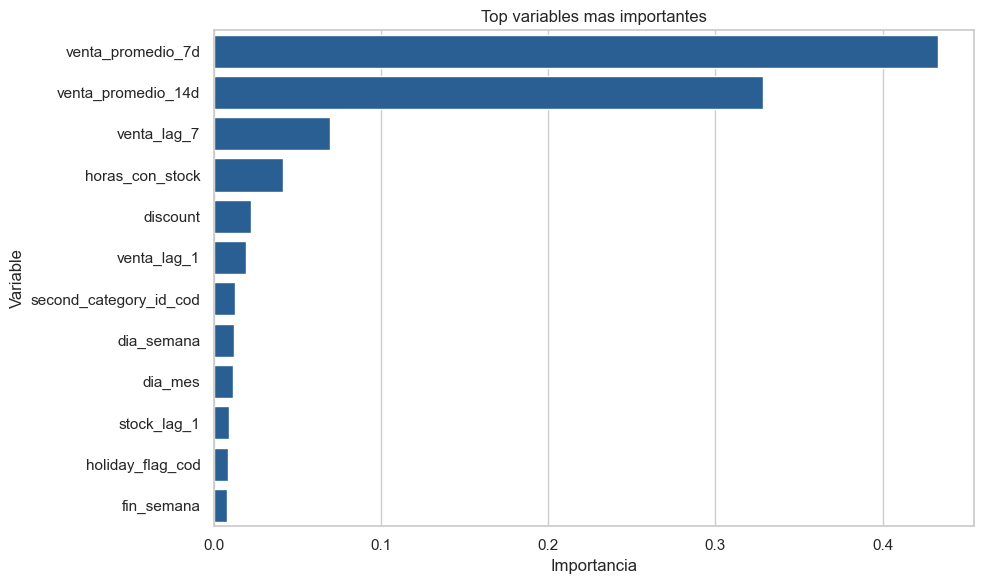

,importancia
venta_promedio_7d,0.433013
venta_promedio_14d,0.328439
venta_lag_7,0.069587
horas_con_stock,0.041615
discount,0.022453
venta_lag_1,0.019523
second_category_id_cod,0.012676
dia_semana,0.012014
dia_mes,0.011623
stock_lag_1,0.009029


In [10]:
importancias = pd.Series(rf.feature_importances_, index=features_existentes).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias.values[:12], y=importancias.index[:12], color="#185FA5")
plt.title("Top variables mas importantes")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

display(importancias.to_frame("importancia"))